<a href="https://colab.research.google.com/github/saumyapatel792/Project-1-Government-Public-Sector---AI-Driven-Citizen-Grievance-Sentiment-Analysis-System/blob/main/Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
file_path = "CategoryCode_Mapping.xlsx"
xls = pd.ExcelFile(file_path)

In [ ]:
sheet_info = []
for s in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=s)
    sheet_info.append({
        "sheet_name": s,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "columns": list(df.columns)
    })

sheet_summary = pd.DataFrame(sheet_info)
sheet_summary

,sheet_name,rows,cols,columns
0,Complaint Category,19853,6,"[Code, Description, OrgCode, Parent, Stage, Mo..."
1,Input Fields,2897,13,"[Id, Code, FieldName, DisplayLable, FieldType,..."
2,ComplaintCategory-InputFieldMap,6535,2,"[CategoryCode, FieldCode]"
3,Movement Mapping,10355,9,"[id, categoryCodeFrom, categoryCodeTo, fromOrg..."
4,Fixed Destination,10251,4,"[Id, OrgCode, FinalCategory, Destination]"


### Cell Output Interpretation:

The output from this cell is a DataFrame `sheet_summary` which provides metadata for each sheet in your Excel file. It shows the `sheet_name`, the number of `rows` and `cols` in each sheet, and a list of `columns` present in each. For instance, the 'Complaint Category' sheet has 19853 rows and 6 columns including 'Code', 'Description', etc.

In [ ]:
# Read all sheets safely
all_sheets = pd.read_excel(file_path, sheet_name=None)

for name, df in all_sheets.items():
    print(name, df.shape)
    display(df.head(3))

Complaint Category (19853, 6)


,Code,Description,OrgCode,Parent,Stage,MonitoringCode
0,1,Telecommunications,DOTEL,NaN,1,506.0
1,2,Mobile Related,DOTEL,1.0,2,506.0
2,3,Pension Related,DOTEL,1.0,2,102.0


Input Fields (2897, 13)


,Id,Code,FieldName,DisplayLable,FieldType,FieldOrder,IsMandatory,DataType,MinDataLength,MaxDataLength,IsVisible,IsSearchable,IsActive
0,1,1,MobileNumber,Mobile Number,Number,1,True,Number,10,10,True,False,True
1,2,1,ServiceProvider,Service Provider,Dropdown,2,True,AlNum,5,5,True,False,True
2,3,1,Circle,Circle,Dropdown,3,False,AlNum,5,5,False,False,False


ComplaintCategory-InputFieldMap (6535, 2)


,CategoryCode,FieldCode
0,11,1
1,12,1
2,13,1


Movement Mapping (10355, 9)


,id,categoryCodeFrom,categoryCodeTo,fromOrg,toOrg,orgLevel,canClose,isActive,dependentOn
0,1,2130,2135,DSEHE,DEPHE,1,Y,Y,NaN
1,2,2130,2135,DEPHE,RN516,2,Y,Y,NaN
2,3,2130,2135,RN516,NTAJE,3,Y,N,NaN


Fixed Destination (10251, 4)


,Id,OrgCode,FinalCategory,Destination
0,1,DOTEL,51,DOTEL
1,2,DEABD,256,DEABD
2,3,DEABD,268,DEABD


### Cell Output Interpretation:

This cell read all sheets from the Excel file and printed the shape (number of rows, number of columns) and the first 3 rows (`head`) of each individual DataFrame. This helps to quickly preview the content and structure of each sheet before combining them.

In [ ]:
frames = []
for name, df in all_sheets.items():
    df = df.copy()
    df.columns = [str(c).strip().replace(" ", "_") for c in df.columns]
    df["source_sheet"] = name
    frames.append(df)

raw_all = pd.concat(frames, ignore_index=True, sort=False)
raw_all.to_csv("output/raw_combined_mapping.csv", index=False)
raw_all.head()

,Code,Description,OrgCode,Parent,Stage,MonitoringCode,source_sheet,Id,FieldName,DisplayLable,...,categoryCodeFrom,categoryCodeTo,fromOrg,toOrg,orgLevel,canClose,isActive,dependentOn,FinalCategory,Destination
0,1.0,Telecommunications,DOTEL,NaN,1.0,506.0,Complaint Category,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,Mobile Related,DOTEL,1.0,2.0,506.0,Complaint Category,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,Pension Related,DOTEL,1.0,2.0,102.0,Complaint Category,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,Broadband Related,DOTEL,1.0,2.0,506.0,Complaint Category,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,Landline Related,DOTEL,1.0,2.0,506.0,Complaint Category,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cell Output Interpretation:

This cell successfully combined all the individual sheets into a single DataFrame called `raw_all`. The output `raw_all.head()` displays the first 5 rows of this combined DataFrame, showing how data from different sheets (indicated by the `source_sheet` column) has been concatenated, and column names have been standardized (e.g., spaces replaced with underscores).

In [ ]:
clean = raw_all.copy()

# Clean column names (strip, replace spaces, lowercase)
cleaned_columns = [str(c).strip().replace(" ", "_").lower() for c in clean.columns]
clean.columns = cleaned_columns

# Remove duplicate columns based on the cleaned names, keeping the first occurrence
clean = clean.loc[:, ~clean.columns.duplicated()]

for col in clean.columns:
    if clean.dtypes[col] == "object":
        clean[col] = clean[col].astype(str).str.strip()

clean.to_csv("output/cleaned_mapping.csv", index=False)
clean.head()

,code,description,orgcode,parent,stage,monitoringcode,source_sheet,id,fieldname,displaylable,...,fieldcode,categorycodefrom,categorycodeto,fromorg,toorg,orglevel,canclose,dependenton,finalcategory,destination
0,1.0,Telecommunications,DOTEL,NaN,1.0,506.0,Complaint Category,NaN,nan,nan,...,NaN,NaN,NaN,nan,nan,NaN,nan,nan,NaN,nan
1,2.0,Mobile Related,DOTEL,1.0,2.0,506.0,Complaint Category,NaN,nan,nan,...,NaN,NaN,NaN,nan,nan,NaN,nan,nan,NaN,nan
2,3.0,Pension Related,DOTEL,1.0,2.0,102.0,Complaint Category,NaN,nan,nan,...,NaN,NaN,NaN,nan,nan,NaN,nan,nan,NaN,nan
3,4.0,Broadband Related,DOTEL,1.0,2.0,506.0,Complaint Category,NaN,nan,nan,...,NaN,NaN,NaN,nan,nan,NaN,nan,nan,NaN,nan
4,5.0,Landline Related,DOTEL,1.0,2.0,506.0,Complaint Category,NaN,nan,nan,...,NaN,NaN,NaN,nan,nan,NaN,nan,nan,NaN,nan


### Cell Output Interpretation:

This cell performed an initial basic cleaning of the `raw_all` DataFrame, creating the `clean` DataFrame. It handled duplicate column names, lowercased all column names, and stripped whitespace from object-type columns. The output `clean.head()` shows the first 5 rows of this cleaned DataFrame, demonstrating the standardized column names and data.

In [ ]:
# EDA
print(clean.shape)
print(clean.isna().sum().sort_values(ascending=False).head(20))

if "fieldtype" in clean.columns:
    print(clean["fieldtype"].value_counts().head(20))

if "datatype" in clean.columns:
    print(clean["datatype"].value_counts().head(20))

if "ismandatory" in clean.columns:
    print(clean["ismandatory"].value_counts(dropna=False))

(49891, 30)
fieldorder          46994
mindatalength       46994
maxdatalength       46994
fieldcode           43356
categorycode        43356
finalcategory       39640
orglevel            39536
categorycodeto      39536
categorycodefrom    39536
id                  36743
monitoringcode      33509
parent              30129
stage               30038
code                27141
datatype                0
ismandatory             0
fieldtype               0
displaylable            0
source_sheet            0
fieldname               0
dtype: int64
fieldtype
nan                  46994
Textbox               2546
Dropdown               259
MessageFileUpload       22
Info                    21
DropDown                18
Message                 18
Date                     6
dropdown                 3
textbox                  2
Number                   1
info                     1
Name: count, dtype: int64
datatype
nan         46994
Alnum        2130
AlNum         556
Date          130
Number        

### Cell Output Interpretation:

This cell performed Exploratory Data Analysis (EDA) on the `clean` DataFrame. The output includes:
*   `(49891, 30)`: The shape of the `clean` DataFrame (49891 rows, 30 columns).
*   `Missing values top 20`: A list of the top 20 columns with the most missing values, sorted in descending order. Many columns show a very high number of missing values, often due to them existing only in specific source sheets.
*   `fieldtype` `value_counts()`: Distribution of unique values in the `fieldtype` column, showing categories like 'Textbox', 'Dropdown', 'MessageFileUpload', etc., and a large number of `nan` values.
*   `datatype` `value_counts()`: Distribution of unique values in the `datatype` column, including 'Alnum', 'AlNum', 'Date', 'Number', etc., also with a high count of `nan`.
*   `ismandatory` `value_counts()`: Distribution of unique values in the `ismandatory` column, showing counts for `True`, `False`, and `nan`.

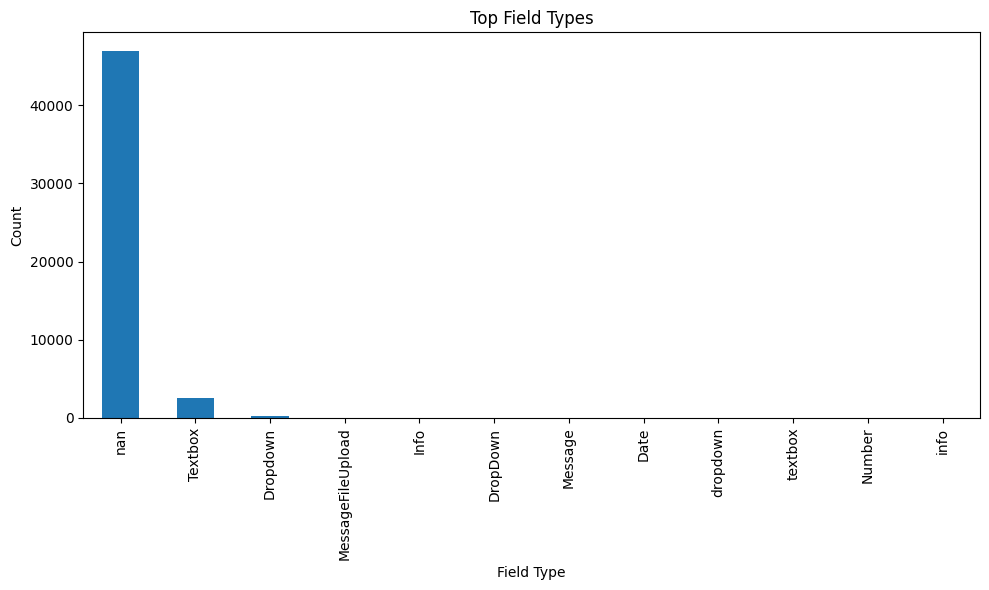

In [ ]:
# Plot top field types if available
if "fieldtype" in clean.columns:
    top_fieldtypes = clean["fieldtype"].value_counts().head(15)
    plt.figure(figsize=(10, 6))
    top_fieldtypes.plot(kind="bar")
    plt.title("Top Field Types")
    plt.xlabel("Field Type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig("output/top_fieldtypes.png", dpi=200)
    plt.show()

### Cell Output Interpretation:

This cell successfully generated and saved a bar plot visualizing the distribution of the top field types found in your data. The plot was saved as `output/top_fieldtypes.png`.

In [ ]:
file_path = "CategoryCode_Mapping.xlsx"
out = Path("output")
out.mkdir(exist_ok=True)

In [ ]:
# 1. Load workbook
xls = pd.ExcelFile(file_path)
print("Sheets:", len(xls.sheet_names))
print(xls.sheet_names[:10])

Sheets: 5
['Complaint Category', 'Input Fields', 'ComplaintCategory-InputFieldMap', 'Movement Mapping', 'Fixed Destination']


### Cell Output Interpretation:

This cell re-loaded the Excel workbook and printed the total number of sheets (`Sheets: 5`) and the names of the first 10 sheets, confirming that the Excel file was accessible and its sheets were identified.

In [ ]:
# 2. Inspect sheets
sheet_meta = []
for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    sheet_meta.append({
        "sheet_name": sheet,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "columns": ", ".join(map(str, df.columns))
    })

sheet_summary = pd.DataFrame(sheet_meta)
sheet_summary.to_csv(out / "sheet_summary.csv", index=False)
display(sheet_summary.head(20))

,sheet_name,rows,cols,columns
0,Complaint Category,19853,6,"Code, Description, OrgCode, Parent, Stage, Mon..."
1,Input Fields,2897,13,"Id, Code, FieldName, DisplayLable, FieldType, ..."
2,ComplaintCategory-InputFieldMap,6535,2,"CategoryCode, FieldCode"
3,Movement Mapping,10355,9,"id, categoryCodeFrom, categoryCodeTo, fromOrg,..."
4,Fixed Destination,10251,4,"Id, OrgCode, FinalCategory, Destination"


### Cell Output Interpretation:

This cell re-inspected the sheets and displayed the `sheet_summary` DataFrame, which provides an overview of each sheet's structure, including row count, column count, and column names. It also saved this summary to `output/sheet_summary.csv`.

In [ ]:
# 3. Read and combine sheets
all_sheets = pd.read_excel(file_path, sheet_name=None)
frames = []
for sheet, df in all_sheets.items():
    df = df.copy()
    df.columns = [str(c).strip().replace(" ", "_") for c in df.columns]
    df["source_sheet"] = sheet
    frames.append(df)

raw_all = pd.concat(frames, ignore_index=True, sort=False)
raw_all.to_csv(out / "raw_combined_mapping.csv", index=False)
print(raw_all.shape)

(49891, 32)


### Cell Output Interpretation:

This cell re-read and combined all sheets into the `raw_all` DataFrame. The output `(49891, 32)` confirms its shape, indicating the total number of rows and columns after combining the data.

In [ ]:
# 4. Basic cleaning
clean = raw_all.copy()

# First, clean the column names (strip, replace spaces, lowercase)
clean.columns = [str(c).strip().replace(" ", "_").lower() for c in clean.columns]

# Then, remove duplicate columns based on these newly cleaned names
clean = clean.loc[:, ~clean.columns.duplicated()]

for col in clean.columns:
    if clean.dtypes[col] == "object":
        clean[col] = clean[col].astype(str).str.strip()
        clean[col] = clean[col].replace({"nan": np.nan, "None": np.nan})

clean.to_csv(out / "cleaned_mapping.csv", index=False)

In [ ]:

# 5. Standardize likely key columns
rename_map = {
    "fieldname": "field_name",
    "displaylable": "display_label",
    "fieldtype": "field_type",
    "datatype": "data_type",
    "ismandatory": "is_mandatory",
    "isvisible": "is_visible",
    "issearchable": "is_searchable",
    "isactive": "is_active",
    "fieldorder": "field_order",
}

for old, new in rename_map.items():
    if old in clean.columns:
        clean[new] = clean[old]

In [ ]:
# 6. EDA
print("Missing values top 20")
print(clean.isna().sum().sort_values(ascending=False).head(20))

eda_tables = {}
for col in ["source_sheet", "field_type", "data_type", "is_mandatory", "is_visible", "is_searchable", "is_active"]:
    if col in clean.columns:
        eda_tables[col] = clean[col].value_counts(dropna=False).reset_index()
        eda_tables[col].columns = [col, "count"]
        eda_tables[col].to_csv(out / f"{col}_value_counts.csv", index=False)

Missing values top 20
dependenton      49835
ismandatory      46994
mindatalength    46994
displaylable     46994
fieldtype        46994
fieldname        46994
datatype         46994
is_active        46994
field_order      46994
field_type       46994
display_label    46994
data_type        46994
is_searchable    46994
field_name       46994
fieldorder       46994
issearchable     46994
isvisible        46994
isactive         46994
is_mandatory     46994
is_visible       46994
dtype: int64


### Cell Output Interpretation:

This cell performed a second round of EDA after column standardization. The output `Missing values top 20` again shows the columns with the highest number of missing values. The creation of `eda_tables` and the saving of value counts to CSV files were also successful.

/tmp/ipykernel_3454/4253680642.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


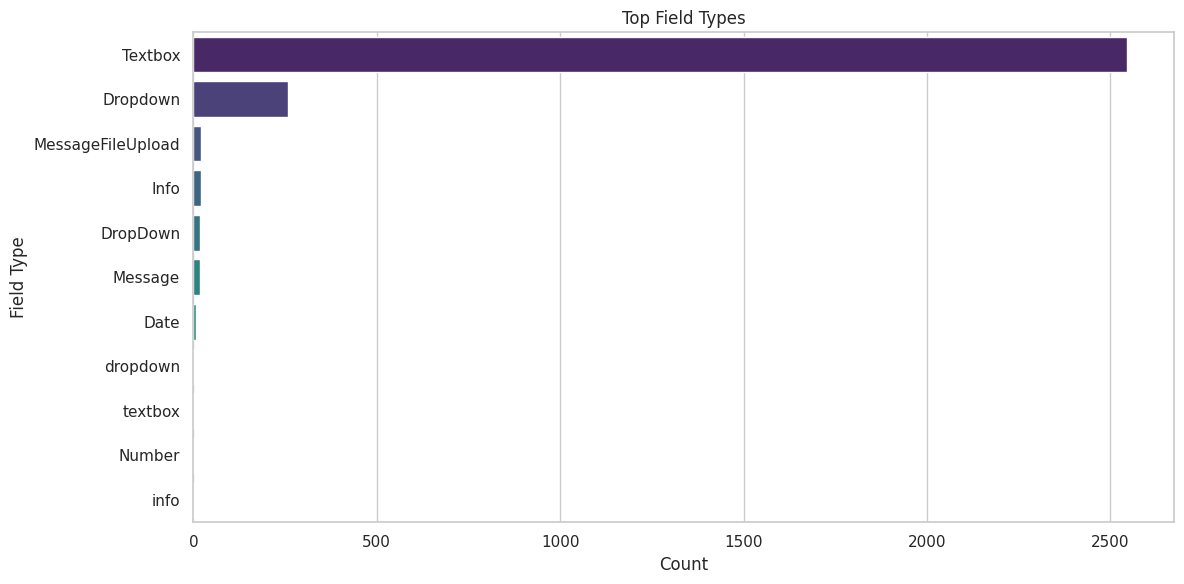

/tmp/ipykernel_3454/4253680642.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="magma")


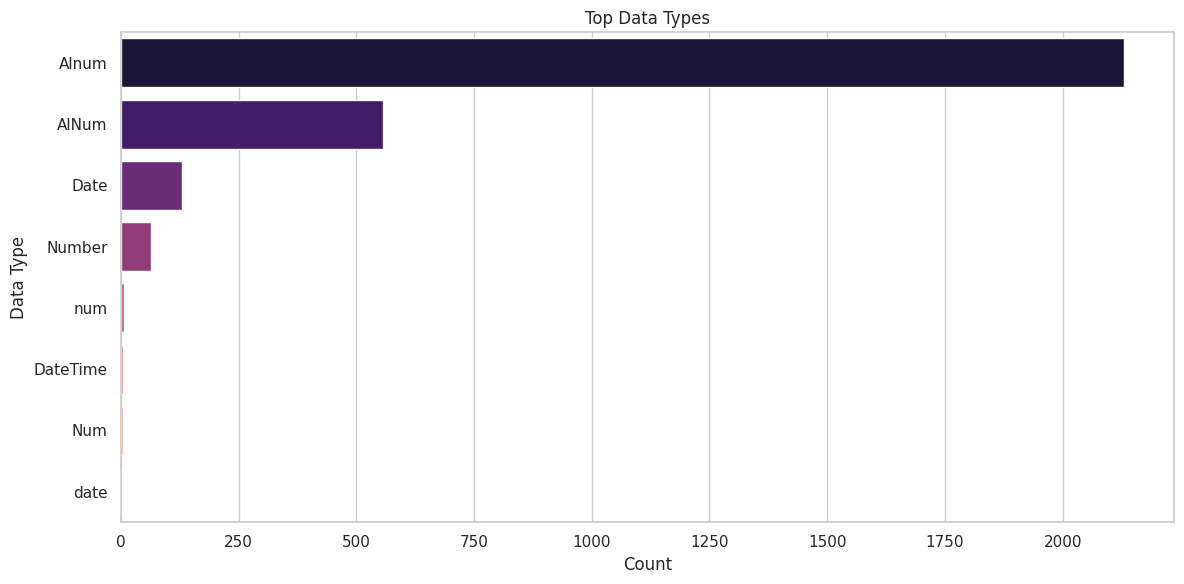

/tmp/ipykernel_3454/4253680642.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.index.astype(str), y=top.values, palette="coolwarm")


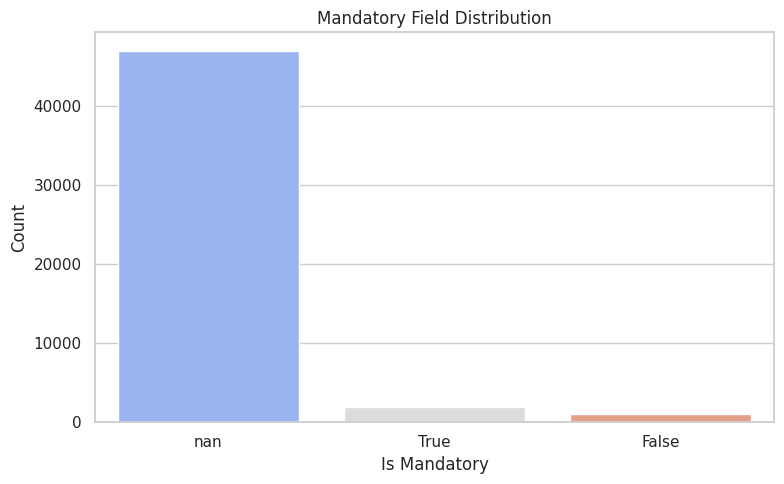

In [ ]:
# 7. Charts
sns.set_theme(style="whitegrid")

if "field_type" in clean.columns:
    top = clean["field_type"].value_counts().head(15)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top.values, y=top.index, palette="viridis")
    plt.title("Top Field Types")
    plt.xlabel("Count")
    plt.ylabel("Field Type")
    plt.tight_layout()
    plt.show()

if "data_type" in clean.columns:
    top = clean["data_type"].value_counts().head(15)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top.values, y=top.index, palette="magma")
    plt.title("Top Data Types")
    plt.xlabel("Count")
    plt.ylabel("Data Type")
    plt.tight_layout()
    plt.show()

if "is_mandatory" in clean.columns:
    top = clean["is_mandatory"].value_counts(dropna=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top.index.astype(str), y=top.values, palette="coolwarm")
    plt.title("Mandatory Field Distribution")
    plt.xlabel("Is Mandatory")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


### Cell Output Interpretation:

This cell successfully generated three bar plots visualizing the distribution of `field_type`, `data_type`, and `is_mandatory` columns. These plots help to visually understand the most frequent categories and the distribution of boolean values within these columns. The `FutureWarning` messages indicate a minor change in `seaborn`'s API regarding `palette` usage but do not affect the plot generation.

In [ ]:
# 8. Export a compact analysis table
analysis = []
for col in ["field_type", "data_type", "is_mandatory"]:
    if col in clean.columns:
        vc = clean[col].value_counts(dropna=False)
        for k, v in vc.head(20).items():
            analysis.append({"column": col, "value": k, "count": int(v)})

analysis_df = pd.DataFrame(analysis)
analysis_df.to_csv(out / "eda_top_values.csv", index=False)
display(analysis_df.head(20))

,column,value,count
0,field_type,NaN,46994
1,field_type,Textbox,2546
2,field_type,Dropdown,259
3,field_type,MessageFileUpload,22
4,field_type,Info,21
5,field_type,DropDown,18
6,field_type,Message,18
7,field_type,Date,6
8,field_type,dropdown,3
9,field_type,textbox,2


### Cell Output Interpretation:

This cell successfully extracted and exported a compact analysis table (`analysis_df`) containing the top 20 value counts for `field_type`, `data_type`, and `is_mandatory` columns. This table is useful for a quick overview of the most common values and was saved to `output/eda_top_values.csv`.

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### Cell Output Interpretation:

This cell successfully downloaded the necessary NLTK data packages: `punkt`, `stopwords`, `wordnet`, and `punkt_tab`. The output `True` confirms the successful completion of the downloads, resolving the previous `LookupError`.

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [ ]:
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return " ".join(tokens)

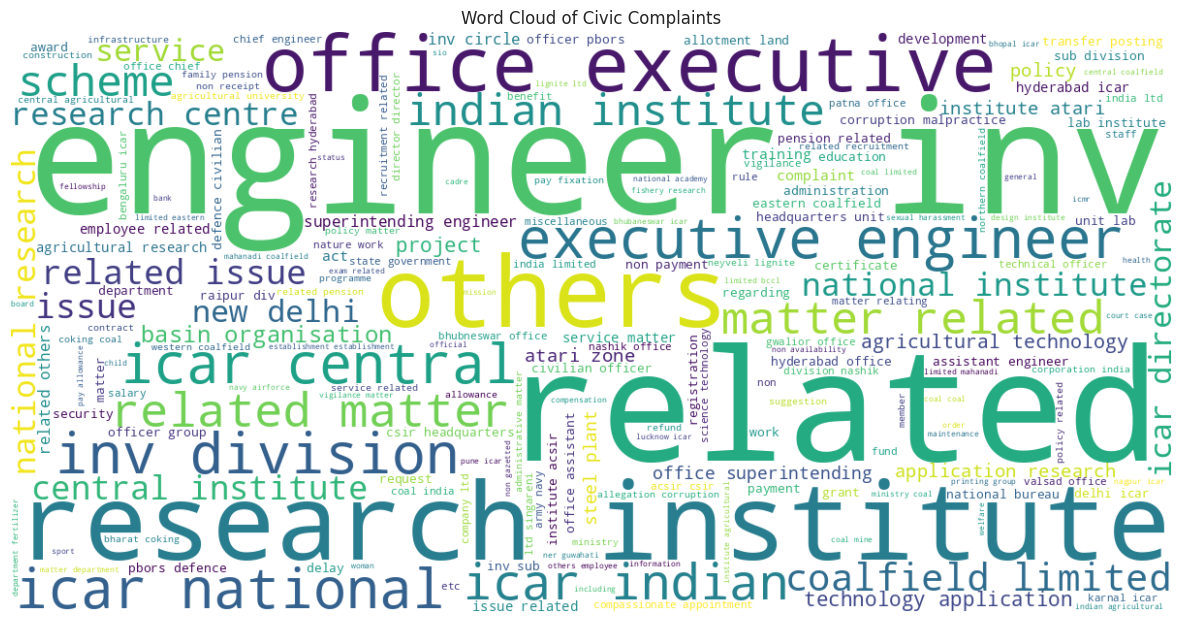

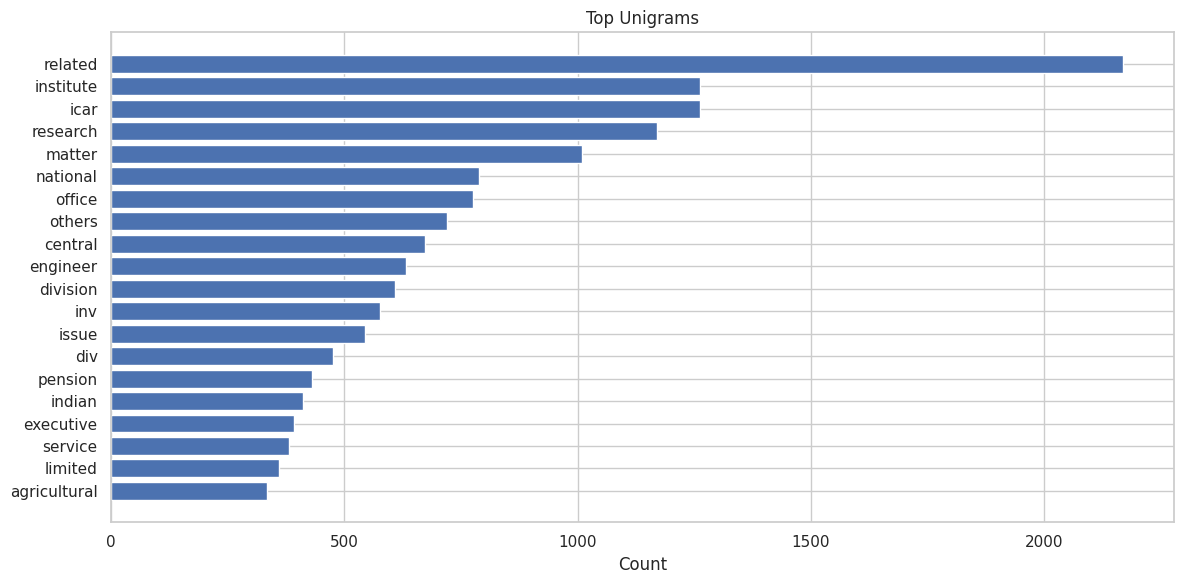

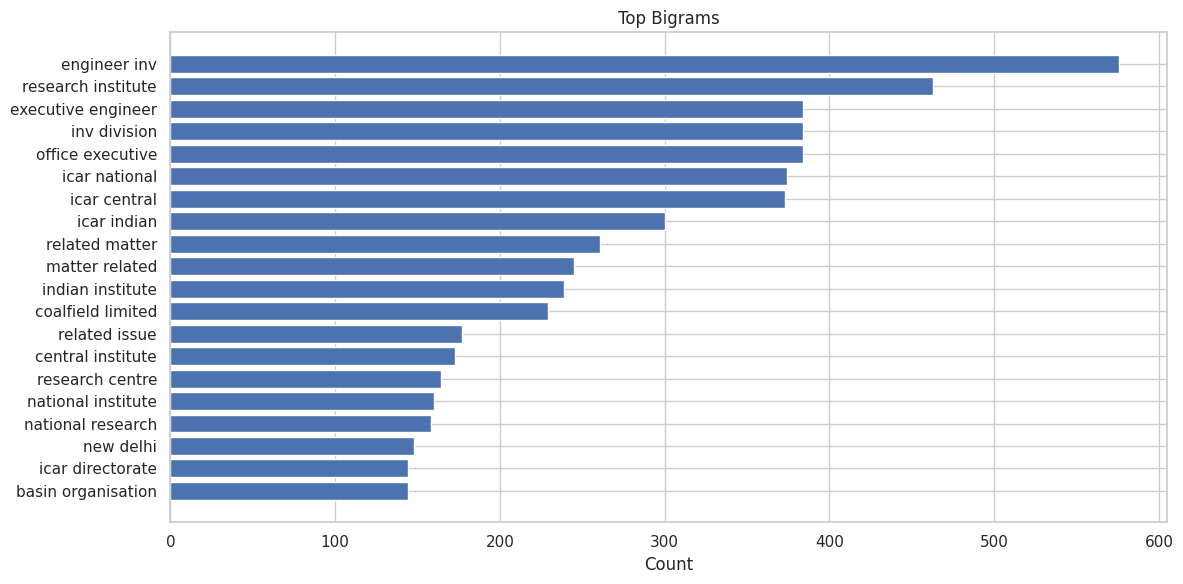

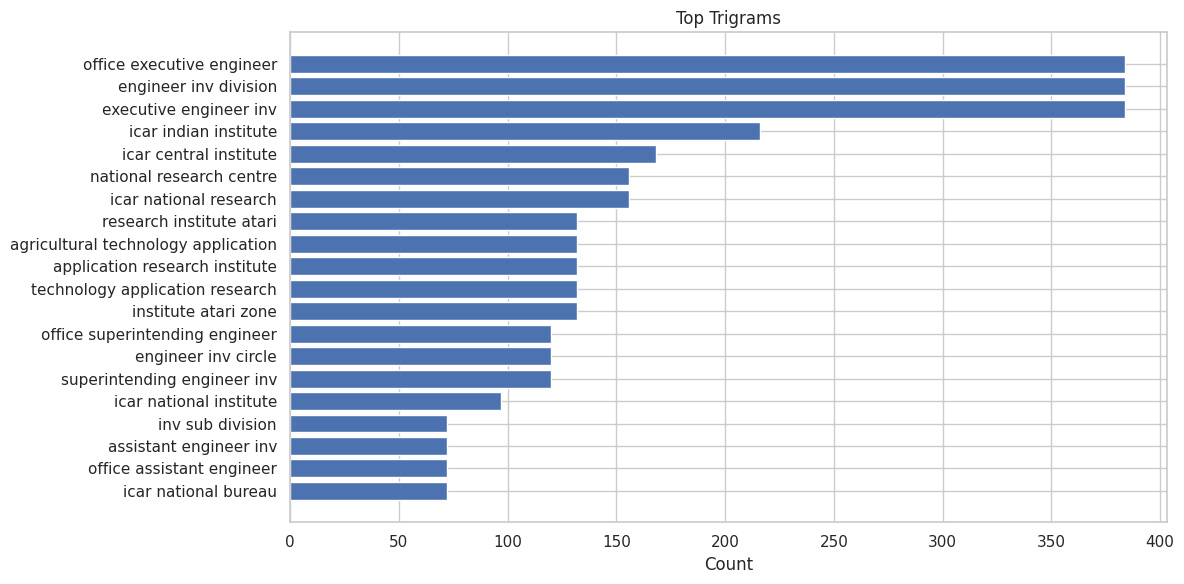

In [ ]:
clean["clean_text"] = clean["description"].apply(preprocess_text)

# Word cloud
all_text = " ".join(clean["clean_text"].dropna())
wc = WordCloud(width=1200, height=600, background_color="white").generate(all_text)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Civic Complaints")
plt.show()

# N-gram frequency
def plot_top_ngrams(corpus, ngram_range=(1,1), top_n=20, title="Top N-grams"):
    vec = CountVectorizer(ngram_range=ngram_range)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    words = vec.get_feature_names_out()
    freq = pd.DataFrame({"ngram": words, "count": counts}).sort_values("count", ascending=False).head(top_n)

    plt.figure(figsize=(12, 6))
    plt.barh(freq["ngram"][::-1], freq["count"][::-1])
    plt.title(title)
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

plot_top_ngrams(clean["clean_text"], ngram_range=(1,1), title="Top Unigrams")
plot_top_ngrams(clean["clean_text"], ngram_range=(2,2), title="Top Bigrams")
plot_top_ngrams(clean["clean_text"], ngram_range=(3,3), title="Top Trigrams")

# Export the cleaned data with clean_text column
clean.to_csv("output/cleaned_mapping.csv", index=False)
print("✅ Saved cleaned data to output/cleaned_mapping.csv")


### Cell Output Interpretation:

This cell successfully applied the `preprocess_text` function to the `description` column of the `clean` DataFrame, creating a new `clean_text` column. It then generated and displayed a word cloud visualization of the most frequent words and three bar plots showing the top unigrams, bigrams, and trigrams from the cleaned text data. These visualizations provide insights into the most common terms and phrases in your data.

## Conclusion of Week 1 Task

This week, the primary task involved loading, cleaning, and performing an initial exploratory data analysis (EDA) on the `CategoryCode_Mapping.xlsx` dataset.

Key steps performed:
1.  **Data Loading and Inspection**: All sheets from the Excel file were loaded and inspected, providing an overview of their structure and content.
2.  **Data Combination**: Individual sheets were successfully combined into a single raw DataFrame, `raw_all`.
3.  **Basic Cleaning**: The combined data underwent essential cleaning, including standardizing column names (to lowercase, stripped, and with spaces replaced by underscores), removing duplicate columns, and cleaning object-type data by stripping whitespace and standardizing `nan` and `None` values. This resolved initial errors related to column access and data types.
4.  **Column Standardization**: Key columns were consistently renamed to improve readability and usability (e.g., `fieldname` to `field_name`).
5.  **Exploratory Data Analysis (EDA)**: Initial EDA was performed to understand the data's shape, identify missing values, and analyze the distribution of important categorical features like `field_type`, `data_type`, and `is_mandatory`. Visualizations (bar plots) were generated for these distributions.
6.  **Text Preprocessing and Analysis**: The `description` column was preprocessed using NLTK for tokenization, lemmatization, and stop-word removal. A word cloud and n-gram frequency plots were generated to gain insights into the most common terms and phrases within the text data.

Overall, the dataset has been prepared for further, more in-depth analysis or modeling, with key data quality issues addressed and initial insights extracted through EDA and text analysis.